# Project 11 - Advanced Plotting - Sarah Liu

In [13]:
# /anvil/projects/tdm/data/zillow/State_time_series.csv

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [15]:
myDF = pd.read_csv('/anvil/projects/tdm/data/zillow/State_time_series.csv')

# 1.1 
myDF['Date'] = pd.to_datetime(myDF['Date'])
selected_regions = ["Indiana", "Tennessee", "Utah", "NewHampshire"]
myDF_selected = myDF[myDF['RegionName'].isin(selected_regions)]
myDF_grouped = myDF_selected.groupby(["Date", "RegionName"], as_index=False).agg(avg_price=("MedianListingPrice_AllHomes", "mean"))

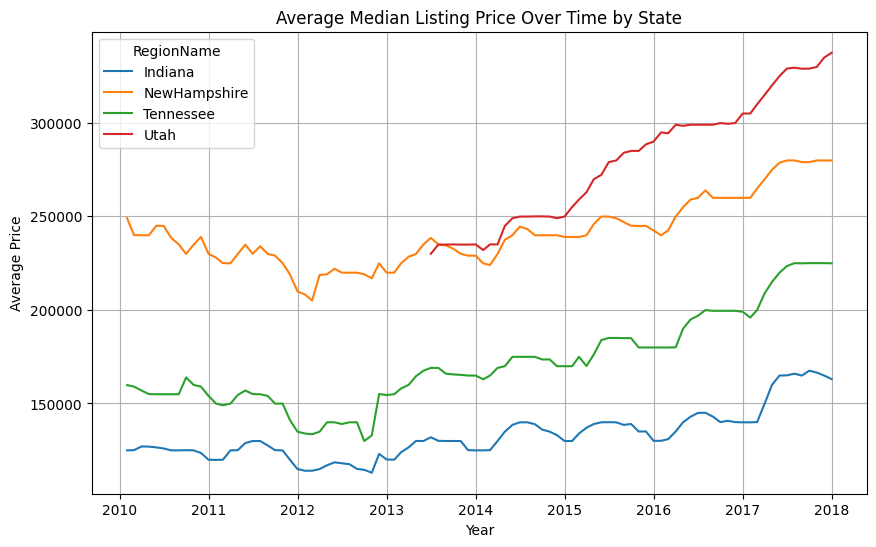

In [16]:
# 1.2 Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(data=myDF_grouped, x="Date", y="avg_price", hue="RegionName")
plt.title("Average Median Listing Price Over Time by State")
plt.xlabel("Year")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()

1.3 the line plot shows that all 4 states show a 
consistent upward trend in median listing prices, with a 
noticeable growth starting in around 2016. Utah and New 
Hampshire maintain significantly higher price points throughout 
the period compared to Indiana and Tennessee.

In [18]:
#2.1 
myDF_cleaned = myDF.dropna(subset=['DaysOnZillow_AllHomes'])

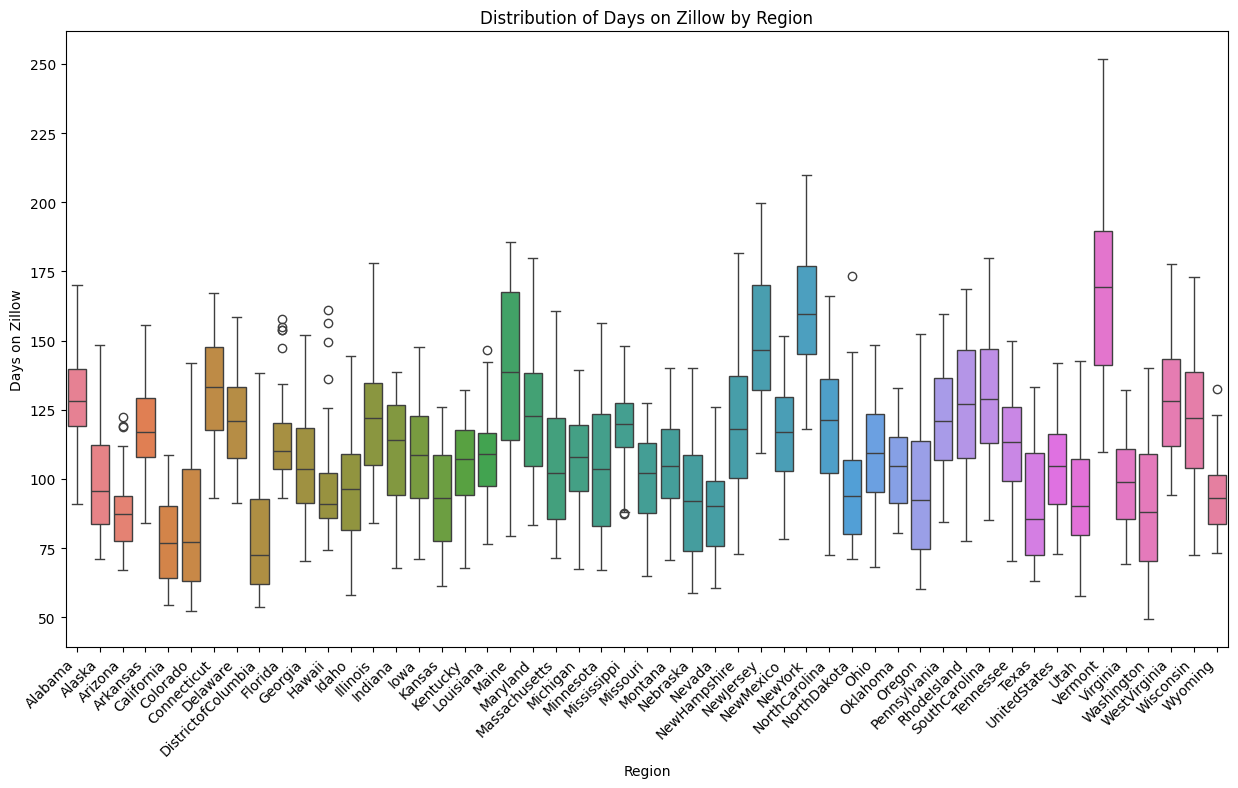

In [19]:
#2.2 
plt.figure(figsize=(15, 8))
sns.boxplot(data=myDF_cleaned, x="RegionName", y="DaysOnZillow_AllHomes", hue="RegionName", legend=False)

#2.3
plt.title("Distribution of Days on Zillow by Region")
plt.xlabel("Region")
plt.ylabel("Days on Zillow")
# Rotate x-axis labels so they don't overlap 
plt.xticks(rotation=45, ha='right')
plt.show()

In [20]:
# list of states for each Census Region
the_northeast = ['Connecticut', 'Maine', 'Massachusetts', 'NewHampshire', 'NewJersey', 'NewYork', 'Pennsylvania', 'RhodeIsland', 'Vermont']
the_midwest = ['Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 'Minnesota', 'Missouri', 'Nebraska', 'NorthDakota', 'Ohio', 'Wisconsin']
the_south = ['Alabama', 'Arkansas', 'Delaware', 'DistrictofColumbia', 'Florida', 'Georgia', 'Kentucky', 'Louisiana', 'Maryland', 'Mississippi', 'NorthCarolina', 'Oklahoma', 'SouthCarolina', 'Tennessee', 'Texas', 'Virginia', 'WestVirginia']
the_west = ['Alaska', 'Arizona', 'California', 'Colorado', 'Hawaii', 'Idaho', 'Montana', 'Nevada', 'NewMexico', 'Oregon', 'Utah', 'Washington', 'Wyoming']

# 3.1 Create the NewRegions column
conditions = [
    myDF_cleaned['RegionName'].isin(the_northeast),
    myDF_cleaned['RegionName'].isin(the_midwest),
    myDF_cleaned['RegionName'].isin(the_south),
    myDF_cleaned['RegionName'].isin(the_west)
]
choices = ['Northeast', 'Midwest', 'South', 'West']
myDF_cleaned['NewRegions'] = np.select(conditions, choices, default='Other')

/tmp/ipykernel_811/644783638.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myDF_cleaned['NewRegions'] = np.select(conditions, choices, default='Other')


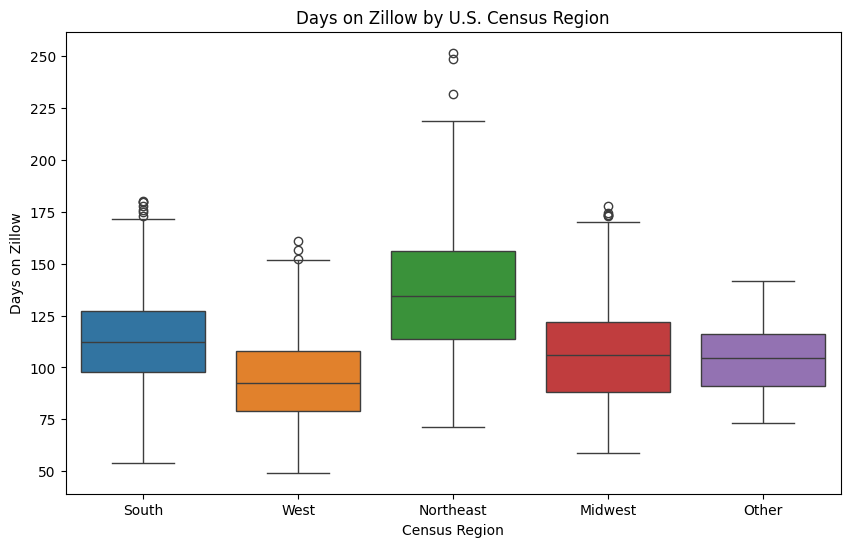

In [21]:
# 3.2 create boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=myDF_cleaned, x="NewRegions", y="DaysOnZillow_AllHomes", hue="NewRegions", legend=False)
plt.title("Days on Zillow by U.S. Census Region")
plt.xlabel("Census Region")
plt.ylabel("Days on Zillow")
plt.show()

3.3 
The West is a "fast" market because there are many buyers but not 
enough houses, so properties sell quickly. The Northeast is a "slower"
and more varied market because many homes are older and unique, which 
requires the right buyer to come along. The South and Midwest are the 
most "balanced" because there is a steady supply of new houses being 
built, which keeps the selling speed consistent.


4.1 
The DaysOnZillow_AllHomes columm represents the demand - selling speed. 
It shows how many days homes that actuall sold stay on the market. 
Higher values menas buyers areslow and lower values show high buyer 
activity.
The InventoryRaw_AllHomes column is the supply - it represents the 
avalibility of homes (current count of how many homes are listed for sale) 
They are related because when supply is high, homes tend to sit on the
market longer because buyers have more choices, while the opposite, when 
supply is low, homes sell faster. This is the concept of market balance. 

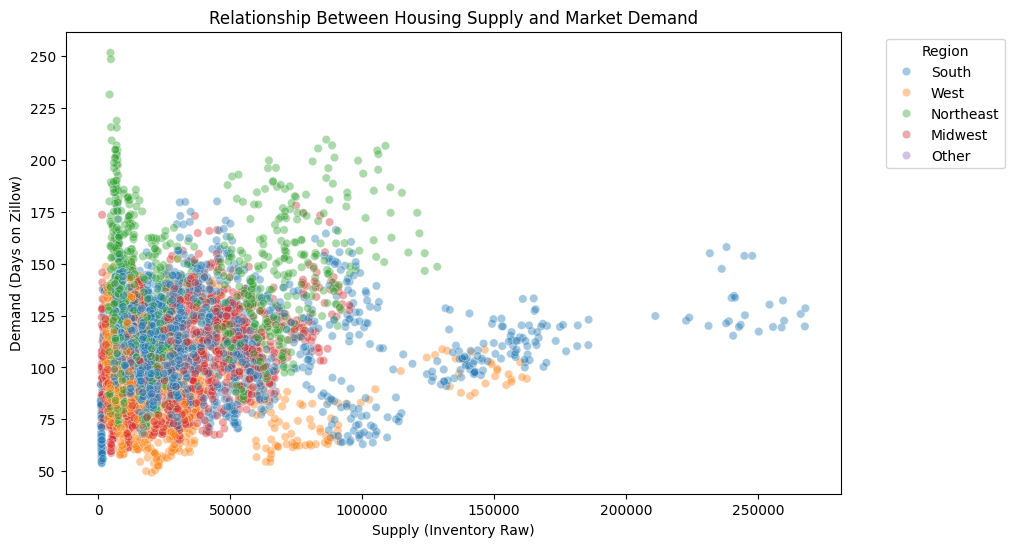

In [29]:
# 4.2 plot Supply vs Demand
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=myDF_cleaned, 
    x="InventoryRaw_AllHomes", 
    y="DaysOnZillow_AllHomes", 
    hue="NewRegions", 
    alpha=0.4
)

plt.title("Relationship Between Housing Supply and Market Demand")
plt.xlabel("Supply (Inventory Raw)")
plt.ylabel("Demand (Days on Zillow)")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

4.3 
- using different colors and shapes for the same category
- using negative values for metrics like time which would make the data 
logically invalid
- overplotting - crowing thousands of data together so the density and 
trends become invisibile
- omitting legneds and labels, making the viewers guess what the data is
Some better practices include using alpha param for transparency so 
overlapping points show density ratehr than a solid blob or using
simplified categories so data is grouped into fewer more meaningful 
regions. Another best practice is to use clear titles and labels with units
so the plot is readable without any other given context. 

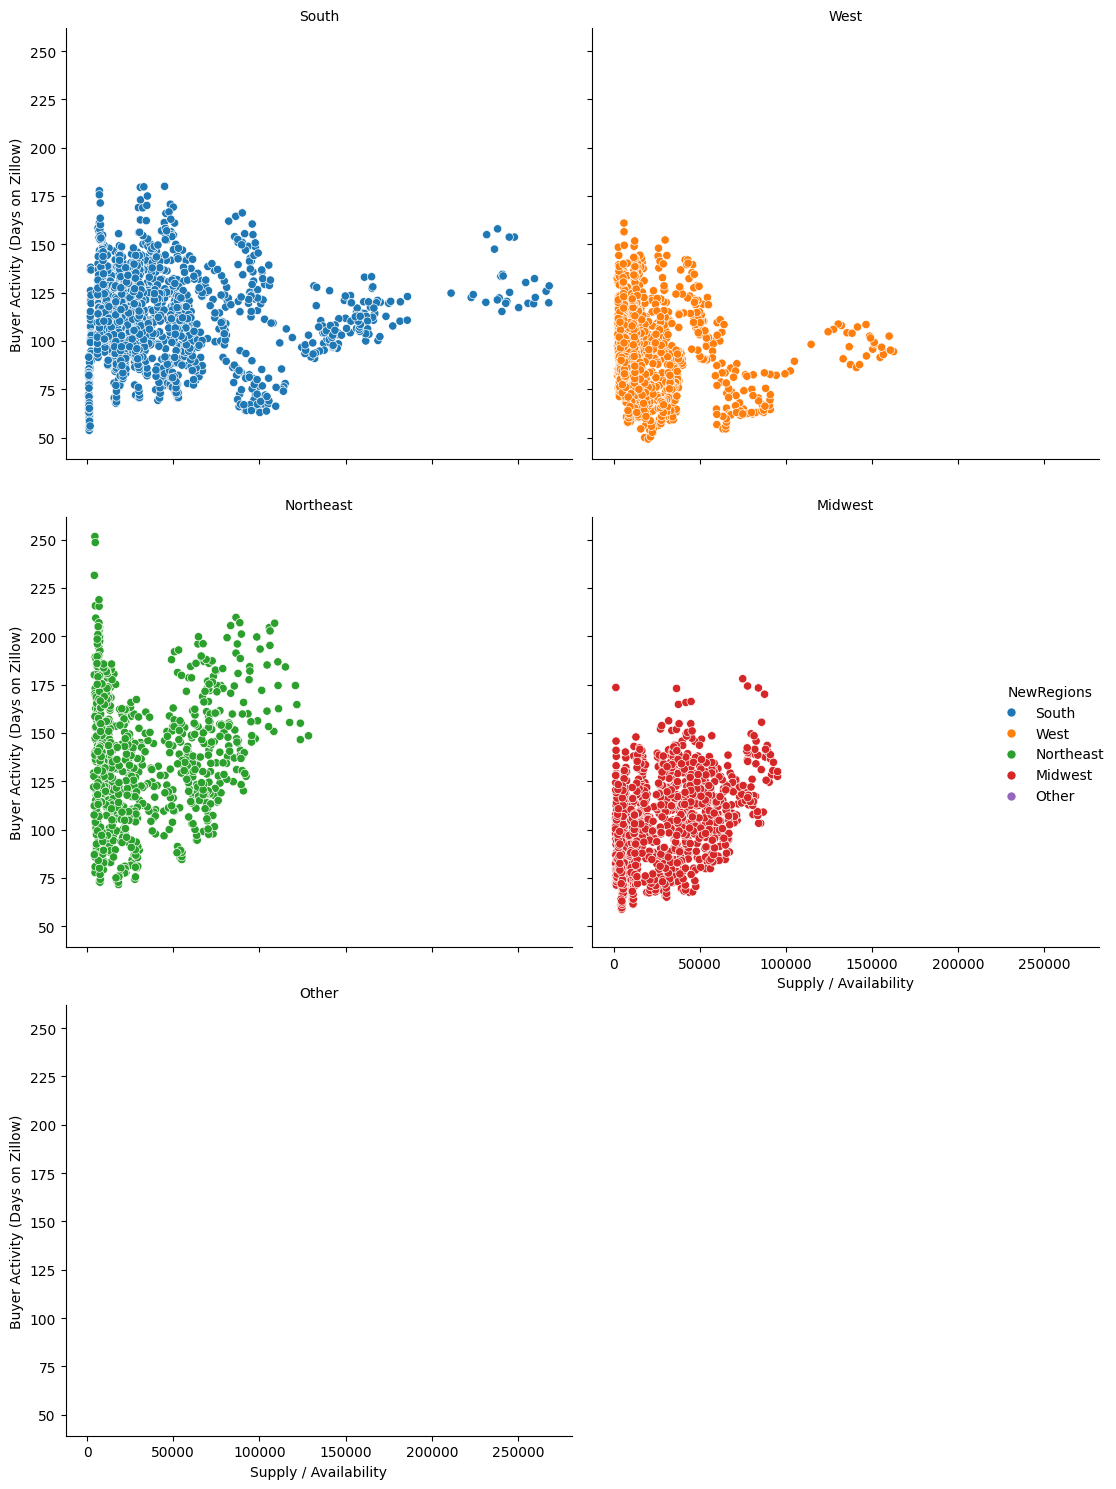

In [27]:
#5.1 
my_plots = sns.relplot(
    data=myDF_cleaned, 
    x="InventoryRaw_AllHomes", 
    y="DaysOnZillow_AllHomes", 
    hue="NewRegions", 
    col="NewRegions", 
    col_wrap=2, 
    kind="scatter"
)

# customize titles and labels
my_plots.set_titles("{col_name}")
my_plots.set_axis_labels("Supply / Availability", "Buyer Activity (Days on Zillow)")
plt.tight_layout()
plt.show()